# Setup

In [1]:
import torch
import time
import random
from typing import Tuple
from tqdm import tqdm

import numpy as np
import pandas as pd
from scapy.all import raw, PcapReader, Ether
import seaborn as sns
import matplotlib.pyplot as plt

import time
from typing import Counter, Tuple
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
DEFAULT_SEED = 10

torch.manual_seed(DEFAULT_SEED)
torch.cuda.manual_seed_all(DEFAULT_SEED)
torch.cuda.manual_seed(DEFAULT_SEED)
torch.mps.manual_seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)
random.seed(DEFAULT_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
def get_overall_metrics(y_true, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
  acc = (tp+tn)/(tp+tn+fp+fn)
  tpr = tp/(tp+fn)
  fpr = fp/(fp+tn)
  precision = tp/(tp+fp)
  f1 = (2*tpr*precision)/(tpr+precision)
  return {'acc':acc,'tpr':tpr,'fpr':fpr,'precision':precision,'f1-score':f1}

def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  group_counts = [f'{value:.0f}' for value in confusion_matrix(y_true, y_pred).ravel()]
  group_percentages = [f'{value*100:.2f}%' for value in confusion_matrix(y_true, y_pred).ravel()/np.sum(cm)]
  labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_counts, group_percentages)]
  labels = np.array(labels).reshape(2,2)
  sns.heatmap(cm, annot=labels, cmap='Oranges', xticklabels=['Predicted Benign', 'Predicted Malicious'], yticklabels=['Actual Benign', 'Actual Malicious'], fmt='')
  return

def get_tpr_per_attack(y_labels, y_pred):
  aux_df = pd.DataFrame({'Label':y_labels,'prediction':y_pred})
  total_per_label = aux_df['Label'].value_counts().to_dict()
  correct_predictions_per_label = aux_df.query('Label != "Normal" and prediction == True').groupby('Label').size().to_dict()
  tpr_per_attack = {}
  for attack_label, total in total_per_label.items():
    if attack_label == 'Normal':
      continue
    tp = correct_predictions_per_label[attack_label] if attack_label in correct_predictions_per_label else 0
    tpr = tp/total
    tpr_per_attack[attack_label] = tpr
  return tpr_per_attack

# Carregando os dados

In [4]:
cache = torch.load(f"train_data_processed.pt", weights_only=False)
X_train_flat, y_train = cache['X_train_flat'], cache['y_train']

In [5]:
X_train_flat.shape

(1203674, 58)

In [14]:
df_feat = pd.DataFrame(X_train_flat, columns=[f"f{i}" for i in range(58)])
cols_with_std = df_feat.std() > 0
selected_cols = df_feat.columns[cols_with_std]
important_features = selected_cols

<Axes: ylabel='Frequency'>

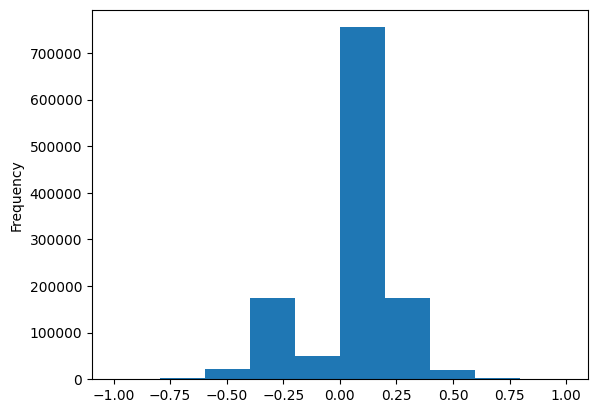

In [21]:
df_feat['f1'].plot.hist()

In [15]:
important_features = [int(i[1:]) for i in important_features]

## 1. Teste de Normalidade (Shapiro-Wilk)

Verifica se as features seguem distribuição normal.

In [8]:
from scipy.stats import shapiro

# Teste de normalidade para algumas features importantes
print("Teste de Normalidade (Shapiro-Wilk)")
print("=" * 50)
print(f"H0: Os dados seguem distribuição normal")
print(f"H1: Os dados não seguem distribuição normal")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in important_features:
    sample = X_train_flat[:, feat_idx][:5000]  # Amostra limitada
    stat, p_value = shapiro(sample)
    result = "Rejeita H0" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: p-value = {p_value:.6f} -> {result}")

Teste de Normalidade (Shapiro-Wilk)
H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05


H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 1: p-value = 0.000000 -> Rejeita H0
Feature 2: p-value = 0.000000 -> Rejeita H0
Feature 3: p-value = 0.000000 -> Rejeita H0
Feature 4: p-value = 0.000000 -> Rejeita H0
Feature 1: p-value = 0.000000 -> Rejeita H0
Feature 2: p-value = 0.000000 -> Rejeita H0
Feature 3: p-value = 0.000000 -> Rejeita H0
Feature 4: p-value = 0.000000 -> Rejeita H0
Feature 11: p-value = 0.000000 -> Rejeita H0
Feature 12: p-value = 0.000000 -> Rejeita H0
Feature 13: p-value = 0.000000 -> Rejeita H0
Feature 14: p-value = 0.000000 -> Rejeita H0
Feature 15: p-value = 0.000000 -> Rejeita H0
Feature 16: p-value = 0.000000 -> Rejeita H0
Feature 17: p-value = 0.000000 -> Rejeita H0
Feature 19: p-value = 0.000000 -> Rejeita H0
Feature 20: p-v

## 2. Teste de Mann-Whitney U

Compara a distribuição de cada feature entre tráfego normal e ataques.

In [9]:
from scipy.stats import mannwhitneyu

# Separar dados normais e ataques
normal_mask = y_train['label'] == 'Normal'
attack_mask = ~normal_mask

print("\nTeste de Mann-Whitney U (Normal vs Ataques)")
print("=" * 50)
print(f"H0: As distribuições são iguais")
print(f"H1: As distribuições são diferentes")
print(f"Nível de significância: α = 0.05\n")

very_important_features = []

for feat_idx in important_features:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    stat, p_value = mannwhitneyu(normal_data, attack_data, alternative='two-sided')
    result = "Rejeita H0 (diferença significativa)" if p_value < 0.05 else "Não rejeita H0"
    if p_value < 0.05:
        very_important_features.append(feat_idx)
    print(f"Feature {feat_idx}: p-value = {p_value:.6e} -> {result}")


Teste de Mann-Whitney U (Normal vs Ataques)
H0: As distribuições são iguais
H1: As distribuições são diferentes
Nível de significância: α = 0.05


H0: As distribuições são iguais
H1: As distribuições são diferentes
Nível de significância: α = 0.05

Feature 1: p-value = 8.401867e-01 -> Não rejeita H0
Feature 1: p-value = 8.401867e-01 -> Não rejeita H0
Feature 2: p-value = 8.401867e-01 -> Não rejeita H0
Feature 3: p-value = 8.401867e-01 -> Não rejeita H0Feature 2: p-value = 8.401867e-01 -> Não rejeita H0
Feature 3: p-value = 8.401867e-01 -> Não rejeita H0
Feature 4: p-value = 8.401867e-01 -> Não rejeita H0
Feature 4: p-value = 8.401867e-01 -> Não rejeita H0

Feature 11: p-value = 7.755041e-01 -> Não rejeita H0
Feature 11: p-value = 7.755041e-01 -> Não rejeita H0
Feature 12: p-value = 8.401867e-01 -> Não rejeita H0Feature 12: p-value = 8.401867e-01 -> Não rejeita H0
Feature 13: p-value = 8.401867e-01 -> Não rejeita H0
Feature 13: p-value = 8.401867e-01 -> Não rejeita H0
Feature 14: p-val

In [10]:
len(very_important_features)

2

## 4. Teste de Correlação (Spearman)

Verifica se há correlação entre as features mais importantes identificadas pelo modelo.

In [11]:
from scipy.stats import spearmanr

print("\nTeste de Correlação de Spearman")
print("=" * 50)
print(f"H0: Não há correlação entre as features")
print(f"H1: Há correlação entre as features")
print(f"Nível de significância: α = 0.05\n")

# Matriz de correlação para features importantes
for i in range(len(very_important_features)):
    for j in range(i+1, len(very_important_features)):
        feat_i, feat_j = very_important_features[i], very_important_features[j]
        corr, p_value = spearmanr(X_train_flat[:, feat_i], X_train_flat[:, feat_j])
        result = "Rejeita H0 (correlação significativa)" if p_value < 0.05 else "Não rejeita H0"
        print(f"Feature {feat_i} vs {feat_j}:\t ρ = {corr:.4f},\t p-value = {p_value:.6e} -> \t\t{result}")


Teste de Correlação de Spearman
H0: Não há correlação entre as features
H1: Há correlação entre as features
Nível de significância: α = 0.05


H0: Não há correlação entre as features
H1: Há correlação entre as features
Nível de significância: α = 0.05

Feature 20 vs 45:	 ρ = 0.0087,	 p-value = 3.050295e-06 -> 		Rejeita H0 (correlação significativa)
Feature 20 vs 45:	 ρ = 0.0087,	 p-value = 3.050295e-06 -> 		Rejeita H0 (correlação significativa)


## 5. Teste de Permutação para Feature Importance

Valida estatisticamente se a importância das features é significativa.

In [12]:
# print("\nTeste de Permutação - Feature Importance")
# print("=" * 50)
# print(f"H0: A feature não tem importância real (baseline)")
# print(f"H1: A feature tem importância significativa")
# print(f"Nível de significância: α = 0.05\n")

# # Usar resultados do PFI já calculado (variável 'train_result' da célula 59)
# # Primeiro, vamos obter o PFI novamente para o conjunto de validação
# from sklearn.inspection import permutation_importance
# pfi_result = permutation_importance(rf, X_val_sub, y_val_sub, n_repeats=50, random_state=DEFAULT_SEED)

# baseline_score = rf.score(X_val_sub, y_val_sub)
# print(f"Baseline accuracy: {baseline_score:.4f}\n")

# # Verificar importância vs erro padrão
# for feat_idx in important_features:
#     mean_importance = pfi_result.importances_mean[feat_idx]
#     std_importance = pfi_result.importances_std[feat_idx]
    
#     # Teste estatístico: importância / erro padrão (t-statistic aproximado)
#     if std_importance > 0:
#         t_stat = mean_importance / std_importance
#         significant = t_stat > 1.96  # Aproximadamente 95% de confiança
#         result_text = "Significativa" if significant else "Não significativa"
#         print(f"Feature {feat_idx}: importance = {mean_importance:.6f} ± {std_importance:.6f} (t = {t_stat:.2f}) -> {result_text}")
#     else:
#         print(f"Feature {feat_idx}: importance = {mean_importance:.6f} (sem variação)")

# Random Forest

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', max_depth=2)

dt.fit(df_feat[selected_cols[:-8]], y_train['label'])

,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
df_feat[selected_cols[:-8]].head()

,f1,f2,f3,f4,f11,f12,f13,f14,f15,f16,...,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.062745,0.0


In [15]:
Yhat_dt = dt.predict(df_feat[selected_cols[:-8]])

In [16]:
get_overall_metrics(y_train['label'], Yhat_dt)

{'acc': np.float64(0.9236579519482692),
 'tpr': np.float64(0.935597603057073),
 'fpr': np.float64(0.12113837290155956),
 'precision': np.float64(0.966641439929973),
 'f1-score': np.float64(0.9508662095316682)}

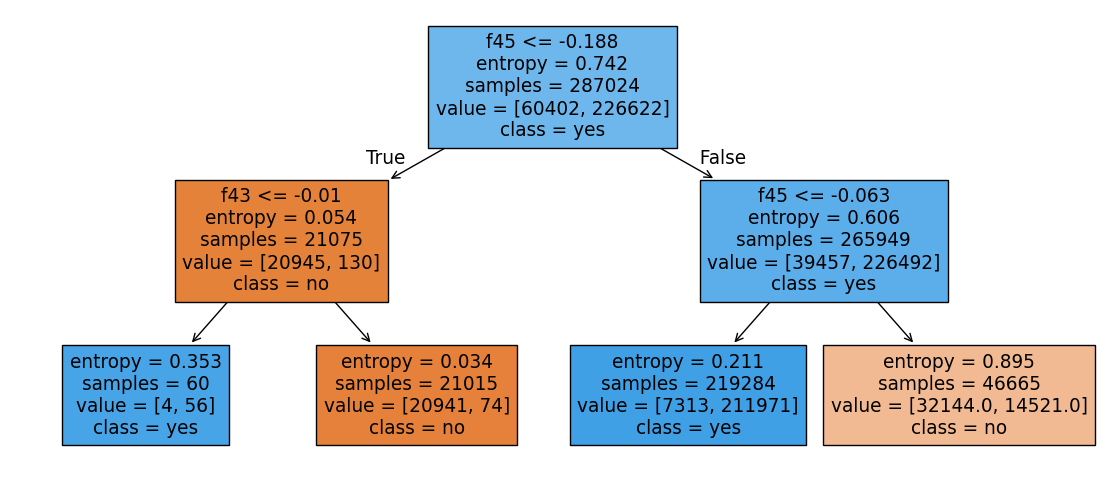

In [17]:
from sklearn import tree

plt.figure(figsize=(14, 6))
tree.plot_tree(dt, class_names=['no', 'yes'], feature_names=df_feat[selected_cols[:-8]].columns, filled=True)

plt.show()

## 6. Teste de Kruskal-Wallis

Compara se há diferença entre múltiplos tipos de ataque para cada feature importante.

In [18]:
from scipy.stats import kruskal

print("\nTeste de Kruskal-Wallis (Múltiplos Tipos de Ataque)")
print("=" * 50)
print(f"H0: As distribuições são iguais entre todos os grupos")
print(f"H1: Pelo menos um grupo tem distribuição diferente")
print(f"Nível de significância: α = 0.05\n")

# Obter tipos únicos de ataques
attack_types = y_train['label'].unique()
attack_types = [at for at in attack_types if at != 'Normal']

# Testar apenas algumas features importantes para não sobrecarregar
for feat_idx in very_important_features[:10]:
    # Criar grupos de dados por tipo de ataque
    groups = []
    for attack_type in attack_types:
        mask = y_train['label'] == attack_type
        group_data = X_train_flat[mask, feat_idx]
        if len(group_data) > 0:  # Apenas adicionar grupos não vazios
            groups.append(group_data)
    
    # Aplicar teste (necessita de pelo menos 2 grupos)
    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
        result = "Rejeita H0 (diferença entre ataques)" if p_value < 0.05 else "Não rejeita H0"
        print(f"Feature {feat_idx}: H = {stat:.4f}, p-value = {p_value:.6e} -> {result}")
    else:
        print(f"Feature {feat_idx}: Dados insuficientes para o teste")


Teste de Kruskal-Wallis (Múltiplos Tipos de Ataque)
H0: As distribuições são iguais entre todos os grupos
H1: Pelo menos um grupo tem distribuição diferente
Nível de significância: α = 0.05

Feature 20: Dados insuficientes para o teste
H0: As distribuições são iguais entre todos os grupos
H1: Pelo menos um grupo tem distribuição diferente
Nível de significância: α = 0.05

Feature 20: Dados insuficientes para o teste
Feature 45: Dados insuficientes para o teste

Feature 45: Dados insuficientes para o teste


## 7. Teste de Wilcoxon (Pareado)

Compara pares de features para verificar se há diferença sistemática entre elas.

In [19]:
from scipy.stats import wilcoxon

print("\nTeste de Wilcoxon (Comparação Pareada de Features)")
print("=" * 50)
print(f"H0: As duas features têm a mesma distribuição")
print(f"H1: As features têm distribuições diferentes")
print(f"Nível de significância: α = 0.05\n")

# Comparar pares de features muito importantes
pairs_to_test = [(very_important_features[i], very_important_features[i+1]) 
                 for i in range(0, min(10, len(very_important_features)-1), 2)]

for feat_i, feat_j in pairs_to_test:
    # Usar apenas dados de ataques
    data_i = X_train_flat[attack_mask, feat_i][:5000]
    data_j = X_train_flat[attack_mask, feat_j][:5000]
    
    stat, p_value = wilcoxon(data_i, data_j)
    result = "Rejeita H0 (distribuições diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_i} vs {feat_j}: W = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Wilcoxon (Comparação Pareada de Features)
H0: As duas features têm a mesma distribuição
H1: As features têm distribuições diferentes
Nível de significância: α = 0.05

Feature 20 vs 45: W = 6244558.5000, p-value = 9.477334e-01 -> Não rejeita H0
H0: As duas features têm a mesma distribuição
H1: As features têm distribuições diferentes
Nível de significância: α = 0.05

Feature 20 vs 45: W = 6244558.5000, p-value = 9.477334e-01 -> Não rejeita H0



## 8. Teste de Kolmogorov-Smirnov

Testa se as distribuições de tráfego normal e ataque são diferentes para cada feature.

In [20]:
from scipy.stats import ks_2samp

print("\nTeste de Kolmogorov-Smirnov (Normal vs Ataques)")
print("=" * 50)
print(f"H0: As duas amostras vêm da mesma distribuição")
print(f"H1: As amostras vêm de distribuições diferentes")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:15]:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    
    stat, p_value = ks_2samp(normal_data, attack_data)
    result = "Rejeita H0 (distribuições diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: D = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Kolmogorov-Smirnov (Normal vs Ataques)
H0: As duas amostras vêm da mesma distribuição
H1: As amostras vêm de distribuições diferentes
Nível de significância: α = 0.05


H0: As duas amostras vêm da mesma distribuição
H1: As amostras vêm de distribuições diferentes
Nível de significância: α = 0.05

Feature 20: D = 0.4882, p-value = 0.000000e+00 -> Rejeita H0 (distribuições diferentes)
Feature 20: D = 0.4882, p-value = 0.000000e+00 -> Rejeita H0 (distribuições diferentes)
Feature 45: D = 0.4681, p-value = 0.000000e+00 -> Rejeita H0 (distribuições diferentes)
Feature 45: D = 0.4681, p-value = 0.000000e+00 -> Rejeita H0 (distribuições diferentes)


## 9. Teste de Levene (Homogeneidade de Variâncias)

Verifica se as variâncias entre tráfego normal e ataques são homogêneas.

In [21]:
from scipy.stats import levene

print("\nTeste de Levene (Homogeneidade de Variâncias)")
print("=" * 50)
print(f"H0: As variâncias são homogêneas entre os grupos")
print(f"H1: As variâncias não são homogêneas")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:15]:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    
    stat, p_value = levene(normal_data, attack_data)
    result = "Rejeita H0 (variâncias diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: W = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Levene (Homogeneidade de Variâncias)
H0: As variâncias são homogêneas entre os grupos
H1: As variâncias não são homogêneas
Nível de significância: α = 0.05


H0: As variâncias são homogêneas entre os grupos
H1: As variâncias não são homogêneas
Nível de significância: α = 0.05

Feature 20: W = 2693.7946, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 45: W = 54935.2925, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 20: W = 2693.7946, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 45: W = 54935.2925, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)


## 10. Teste Qui-Quadrado para Independência

Testa se a classificação binária (Normal vs Ataque) é independente de faixas de valores das features.

In [22]:
from scipy.stats import chi2_contingency

print("\nTeste Qui-Quadrado de Independência")
print("=" * 50)
print(f"H0: A classificação é independente dos valores da feature")
print(f"H1: Há dependência entre classificação e valores da feature")
print(f"Nível de significância: α = 0.05\n")

# Criar variável binária para Normal vs Ataque
y_binary = (y_train['label'] != 'Normal').astype(int)

for feat_idx in very_important_features[:10]:
    # Discretizar a feature em quartis
    feature_data = X_train_flat[:, feat_idx]
    quartiles = pd.qcut(feature_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    
    # Criar tabela de contingência
    contingency_table = pd.crosstab(quartiles, y_binary)
    
    # Aplicar teste
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    result = "Rejeita H0 (há dependência)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: χ² = {chi2:.4f}, p-value = {p_value:.6e} -> {result}")


Teste Qui-Quadrado de Independência
H0: A classificação é independente dos valores da feature
H1: Há dependência entre classificação e valores da feature
H0: A classificação é independente dos valores da feature
H1: Há dependência entre classificação e valores da feature
Nível de significância: α = 0.05


Nível de significância: α = 0.05

Feature 20: χ² = 19212.6036, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 20: χ² = 19212.6036, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 45: χ² = 85880.3561, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 45: χ² = 85880.3561, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)


## 11. Teste de Anderson-Darling

Verifica normalidade com mais sensibilidade nas caudas da distribuição.

In [23]:
from scipy.stats import anderson

print("\nTeste de Anderson-Darling (Normalidade)")
print("=" * 50)
print(f"H0: Os dados seguem distribuição normal")
print(f"H1: Os dados não seguem distribuição normal")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:15]:
    sample = X_train_flat[:, feat_idx][:5000]
    result = anderson(sample, dist='norm')
    
    # Verificar contra nível de significância de 5%
    critical_value_5pct = result.critical_values[2]  # Índice 2 corresponde a 5%
    if result.statistic > critical_value_5pct:
        decision = "Rejeita H0 (não é normal)"
    else:
        decision = "Não rejeita H0"
    
    print(f"Feature {feat_idx}: A² = {result.statistic:.4f}, Valor Crítico(5%) = {critical_value_5pct:.4f} -> {decision}")


Teste de Anderson-Darling (Normalidade)
H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 20: A² = 1223.0023, Valor Crítico(5%) = 0.7860 -> Rejeita H0 (não é normal)
Feature 45: A² = 1724.4217, Valor Crítico(5%) = 0.7860 -> Rejeita H0 (não é normal)

H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 20: A² = 1223.0023, Valor Crítico(5%) = 0.7860 -> Rejeita H0 (não é normal)
Feature 45: A² = 1724.4217, Valor Crítico(5%) = 0.7860 -> Rejeita H0 (não é normal)


## 12. Teste de Friedman

Compara múltiplos tipos de ataque (versão não-paramétrica de ANOVA com medidas repetidas).

In [27]:
from scipy.stats import friedmanchisquare

print("\nTeste de Friedman (Comparação de Múltiplas Features)")
print("=" * 50)
print(f"H0: Todas as features têm a mesma distribuição")
print(f"H1: Pelo menos uma feature tem distribuição diferente")
print(f"Nível de significância: α = 0.05\n")

# Comparar as top features muito importantes apenas para dados de ataque
# Friedman requer pelo menos 3 grupos
n_features = min(7, len(very_important_features))

if n_features >= 3:
    features_data = []
    sample_size = min(1000, np.sum(attack_mask))
    
    for i in range(n_features):
        feat_idx = very_important_features[i]
        features_data.append(X_train_flat[attack_mask, feat_idx][:sample_size])
    
    stat, p_value = friedmanchisquare(*features_data)
    result = "Rejeita H0 (diferença entre features)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Top {n_features} features: χ²_F = {stat:.4f}, p-value = {p_value:.6e} -> {result}")
else:
    print(f"Dados insuficientes: necessário pelo menos 3 features, mas apenas {n_features} disponíveis")


Teste de Friedman (Comparação de Múltiplas Features)
H0: Todas as features têm a mesma distribuição
H1: Pelo menos uma feature tem distribuição diferente
Nível de significância: α = 0.05

Dados insuficientes: necessário pelo menos 3 features, mas apenas 2 disponíveis

H0: Todas as features têm a mesma distribuição
H1: Pelo menos uma feature tem distribuição diferente
Nível de significância: α = 0.05

Dados insuficientes: necessário pelo menos 3 features, mas apenas 2 disponíveis


## 13. Teste de Mood (Igualdade de Escalas)

Testa se duas amostras têm a mesma escala (dispersão), alternativa robusta ao teste de Levene.

In [28]:
from scipy.stats import mood

print("\nTeste de Mood (Igualdade de Escalas)")
print("=" * 50)
print(f"H0: As duas amostras têm a mesma escala")
print(f"H1: As amostras têm escalas diferentes")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:10]:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    
    stat, p_value = mood(normal_data, attack_data)
    result = "Rejeita H0 (escalas diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: z = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Mood (Igualdade de Escalas)
H0: As duas amostras têm a mesma escala
H1: As amostras têm escalas diferentes
Nível de significância: α = 0.05


H0: As duas amostras têm a mesma escala
H1: As amostras têm escalas diferentes
Nível de significância: α = 0.05

Feature 20: z = -68.8177, p-value = 0.000000e+00 -> Rejeita H0 (escalas diferentes)
Feature 20: z = -68.8177, p-value = 0.000000e+00 -> Rejeita H0 (escalas diferentes)
Feature 45: z = -320.5654, p-value = 0.000000e+00 -> Rejeita H0 (escalas diferentes)
Feature 45: z = -320.5654, p-value = 0.000000e+00 -> Rejeita H0 (escalas diferentes)


## 14. Teste de Ansari-Bradley

Testa se duas amostras têm a mesma dispersão (variância), sensível a diferenças nas caudas.

In [29]:
from scipy.stats import ansari

print("\nTeste de Ansari-Bradley (Dispersão)")
print("=" * 50)
print(f"H0: As dispersões são iguais")
print(f"H1: As dispersões são diferentes")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:10]:
    normal_data = X_train_flat[normal_mask, feat_idx][:5000]
    attack_data = X_train_flat[attack_mask, feat_idx][:5000]
    
    stat, p_value = ansari(normal_data, attack_data)
    result = "Rejeita H0 (dispersões diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: AB = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Ansari-Bradley (Dispersão)
H0: As dispersões são iguais
H1: As dispersões são diferentes
Nível de significância: α = 0.05


H0: As dispersões são iguais
H1: As dispersões são diferentes
Nível de significância: α = 0.05

Feature 20: AB = 13180563.0000, p-value = 1.858200e-21 -> Rejeita H0 (dispersões diferentes)
Feature 45: AB = 17341584.0000, p-value = 0.000000e+00 -> Rejeita H0 (dispersões diferentes)
Feature 20: AB = 13180563.0000, p-value = 1.858200e-21 -> Rejeita H0 (dispersões diferentes)
Feature 45: AB = 17341584.0000, p-value = 0.000000e+00 -> Rejeita H0 (dispersões diferentes)


## 15. Teste de Fligner-Killeen

Versão não-paramétrica do teste de homogeneidade de variâncias, mais robusta que Levene.

In [30]:
from scipy.stats import fligner

print("\nTeste de Fligner-Killeen (Homogeneidade de Variâncias)")
print("=" * 50)
print(f"H0: As variâncias são homogêneas")
print(f"H1: As variâncias não são homogêneas")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:10]:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    
    stat, p_value = fligner(normal_data, attack_data)
    result = "Rejeita H0 (variâncias diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: H = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Fligner-Killeen (Homogeneidade de Variâncias)
H0: As variâncias são homogêneas
H1: As variâncias não são homogêneas
Nível de significância: α = 0.05


H0: As variâncias são homogêneas
H1: As variâncias não são homogêneas
Nível de significância: α = 0.05

Feature 20: H = 18075.2982, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 20: H = 18075.2982, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 45: H = 87606.1286, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)
Feature 45: H = 87606.1286, p-value = 0.000000e+00 -> Rejeita H0 (variâncias diferentes)


## 16. Teste de Jarque-Bera

Testa normalidade baseando-se na assimetria e curtose da distribuição.

In [31]:
from scipy.stats import jarque_bera

print("\nTeste de Jarque-Bera (Normalidade)")
print("=" * 50)
print(f"H0: Os dados seguem distribuição normal")
print(f"H1: Os dados não seguem distribuição normal")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in important_features[:15]:
    sample = X_train_flat[:, feat_idx]
    stat, p_value = jarque_bera(sample)
    result = "Rejeita H0 (não é normal)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: JB = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Jarque-Bera (Normalidade)
H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05


H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 1: JB = 44841005056.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 2: JB = 44841021440.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)Feature 1: JB = 44841005056.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 2: JB = 44841021440.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 3: JB = 44840996864.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)

Feature 3: JB = 44840996864.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 4: JB = 44840996864.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 11: JB = 179641991168.0000, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)Feature 4: JB = 44840996864.0000, p-va

## 17. Teste de Normalidade de D'Agostino-Pearson

Combina testes de assimetria e curtose para avaliar normalidade.

In [32]:
from scipy.stats import normaltest

print("\nTeste de D'Agostino-Pearson (Normalidade)")
print("=" * 50)
print(f"H0: Os dados seguem distribuição normal")
print(f"H1: Os dados não seguem distribuição normal")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in important_features[:15]:
    sample = X_train_flat[:, feat_idx]
    stat, p_value = normaltest(sample)
    result = "Rejeita H0 (não é normal)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: K² = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de D'Agostino-Pearson (Normalidade)
H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05


H0: Os dados seguem distribuição normal
H1: Os dados não seguem distribuição normal
Nível de significância: α = 0.05

Feature 1: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 2: K² = 159099.2500, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)Feature 1: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 2: K² = 159099.2500, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)

Feature 3: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 3: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 4: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)
Feature 11: K² = 165522.9062, p-value = 0.000000e+00 -> Rejeita H0 (não é normal)Feature 4: K² = 159099.2188, p-value = 0.000000e+00 -> Rejeita H0 (não é

## 18. Teste de Mediana (Mood's Median Test)

Testa se duas ou mais amostras têm a mesma mediana.

In [33]:
from scipy.stats import median_test

print("\nTeste de Mediana (Mood's Median Test)")
print("=" * 50)
print(f"H0: As medianas são iguais")
print(f"H1: As medianas são diferentes")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:10]:
    normal_data = X_train_flat[normal_mask, feat_idx]
    attack_data = X_train_flat[attack_mask, feat_idx]
    
    stat, p_value, med, tbl = median_test(normal_data, attack_data)
    result = "Rejeita H0 (medianas diferentes)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: χ² = {stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Mediana (Mood's Median Test)
H0: As medianas são iguais
H1: As medianas são diferentes
Nível de significância: α = 0.05


H0: As medianas são iguais
H1: As medianas são diferentes
Nível de significância: α = 0.05

Feature 20: χ² = 9972.3341, p-value = 0.000000e+00 -> Rejeita H0 (medianas diferentes)
Feature 45: χ² = 6750.1329, p-value = 0.000000e+00 -> Rejeita H0 (medianas diferentes)
Feature 20: χ² = 9972.3341, p-value = 0.000000e+00 -> Rejeita H0 (medianas diferentes)
Feature 45: χ² = 6750.1329, p-value = 0.000000e+00 -> Rejeita H0 (medianas diferentes)


## 19. Teste de Razão de Verossimilhança (G-test)

Alternativa ao qui-quadrado para testar independência em tabelas de contingência.

In [34]:
from scipy.stats import chi2_contingency

print("\nTeste G (Razão de Verossimilhança)")
print("=" * 50)
print(f"H0: A classificação é independente dos valores da feature")
print(f"H1: Há dependência entre classificação e valores da feature")
print(f"Nível de significância: α = 0.05\n")

y_binary = (y_train['label'] != 'Normal').astype(int)

for feat_idx in very_important_features[:8]:
    feature_data = X_train_flat[:, feat_idx]
    quartiles = pd.qcut(feature_data, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    contingency_table = pd.crosstab(quartiles, y_binary)
    
    # lambda_="log-likelihood" usa G-test ao invés de qui-quadrado
    g_stat, p_value, dof, expected = chi2_contingency(contingency_table, lambda_="log-likelihood")
    result = "Rejeita H0 (há dependência)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: G = {g_stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste G (Razão de Verossimilhança)
H0: A classificação é independente dos valores da feature
H1: Há dependência entre classificação e valores da feature
Nível de significância: α = 0.05


H0: A classificação é independente dos valores da feature
H1: Há dependência entre classificação e valores da feature
Nível de significância: α = 0.05

Feature 20: G = 25077.1972, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 20: G = 25077.1972, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 45: G = 81083.8164, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)
Feature 45: G = 81083.8164, p-value = 0.000000e+00 -> Rejeita H0 (há dependência)


## 20. Teste de Runs (Aleatoriedade)

Testa se uma sequência de dados é aleatória ou apresenta padrões sistemáticos.

In [35]:
from scipy.stats import rankdata
from scipy.stats import norm as normal_dist

def runs_test(data):
    """Implementa teste de runs para sequências."""
    median = np.median(data)
    runs = np.diff(data > median).astype(int)
    n_runs = np.sum(np.abs(runs)) + 1
    
    n_above = np.sum(data > median)
    n_below = len(data) - n_above
    
    if n_above == 0 or n_below == 0:
        return 0, 1.0  # Não há variabilidade
    
    expected_runs = (2 * n_above * n_below) / (n_above + n_below) + 1
    var_runs = (2 * n_above * n_below * (2 * n_above * n_below - n_above - n_below)) / \
               ((n_above + n_below)**2 * (n_above + n_below - 1))
    
    if var_runs == 0:
        return 0, 1.0
    
    z_stat = (n_runs - expected_runs) / np.sqrt(var_runs)
    p_value = 2 * (1 - normal_dist.cdf(abs(z_stat)))
    
    return z_stat, p_value

print("\nTeste de Runs (Aleatoriedade)")
print("=" * 50)
print(f"H0: A sequência é aleatória")
print(f"H1: A sequência não é aleatória (há padrões)")
print(f"Nível de significância: α = 0.05\n")

for feat_idx in very_important_features[:8]:
    # Testar aleatoriedade em dados de ataque
    sample = X_train_flat[attack_mask, feat_idx][:1000]
    z_stat, p_value = runs_test(sample)
    result = "Rejeita H0 (há padrões)" if p_value < 0.05 else "Não rejeita H0"
    print(f"Feature {feat_idx}: z = {z_stat:.4f}, p-value = {p_value:.6e} -> {result}")


Teste de Runs (Aleatoriedade)
H0: A sequência é aleatória
H1: A sequência não é aleatória (há padrões)
Nível de significância: α = 0.05

Feature 20: z = -28.4114, p-value = 0.000000e+00 -> Rejeita H0 (há padrões)

H0: A sequência é aleatória
H1: A sequência não é aleatória (há padrões)
Nível de significância: α = 0.05

Feature 20: z = -28.4114, p-value = 0.000000e+00 -> Rejeita H0 (há padrões)
Feature 45: z = -24.0434, p-value = 0.000000e+00 -> Rejeita H0 (há padrões)
Feature 45: z = -24.0434, p-value = 0.000000e+00 -> Rejeita H0 (há padrões)


# Testes de Hipótese Focados em Detecção de Intrusão

Testes mais robustos que relacionam o comportamento da rede com o desempenho do sistema.

## Carregando Dataset Completo

Carregando o dataset com TODOS os tipos de ataque para análises mais robustas.

In [8]:
# Carregar dataset completo com todos os ataques
cache_full = torch.load(f"train_data_processed.pt", weights_only=False)
X_full = cache_full['X_train_flat']
y_full = cache_full['y_train']

print(f"Dataset Completo:")
print(f"  Total de amostras: {len(X_full):,}")
print(f"  Shape: {X_full.shape}")
print(f"\nDistribuição de Classes:")
print(y_full['label'].value_counts())
print(f"\nTipos de Ataque: {y_full['label'].nunique()} classes diferentes")

Dataset Completo:
  Total de amostras: 1,203,674
  Shape: (1203674, 58)

Distribuição de Classes:
label
Normal                 550090
PTP Sync               193460
CAN DoS                178730
Switch MAC Flooding    104429
CAN Replay             101649
Frame Injection         75316
Name: count, dtype: int64

Tipos de Ataque: 6 classes diferentes


## Preparação: Treinamento do Modelo Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Preparar dados para modelagem usando o DATASET COMPLETO
X = X_full
y = (y_full['label'] != 'Normal').astype(int)  # Binário: 0=Normal, 1=Ataque

# Split para treino e teste
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.3, random_state=DEFAULT_SEED, stratify=y
)

# Treinar Random Forest
print("Treinando Random Forest com dataset completo...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=DEFAULT_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_split, y_train_split)

# Fazer predições
y_pred_train = rf_model.predict(X_train_split)
y_pred_test = rf_model.predict(X_test_split)

# Métricas gerais
from sklearn.metrics import accuracy_score, classification_report
print(f"\nAcurácia no treino: {accuracy_score(y_train_split, y_pred_train):.4f}")
print(f"Acurácia no teste: {accuracy_score(y_test_split, y_pred_test):.4f}")
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test_split, y_pred_test, target_names=['Normal', 'Ataque']))

Treinando Random Forest com dataset completo...

Acurácia no treino: 0.8662
Acurácia no teste: 0.8651

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

      Normal       0.80      0.93      0.86    165027
      Ataque       0.94      0.81      0.87    196076

    accuracy                           0.87    361103
   macro avg       0.87      0.87      0.87    361103
weighted avg       0.88      0.87      0.87    361103



## 21. O tipo de ataque influencia a eficácia da detecção?

**Pergunta**: Alguns ataques são mais fáceis de detectar que outros?

**Contexto**: Ataques "barulhentos" (DoS) são mais fáceis de detectar que ataques "silenciosos" (Replay).

In [10]:
from scipy.stats import chi2_contingency

print("\n" + "="*70)
print("TESTE 21: Tipo de Ataque vs Eficácia de Detecção")
print("="*70)
print(f"H0: A taxa de detecção é igual para todos os tipos de ataque")
print(f"H1: Pelo menos um tipo de ataque tem taxa de detecção diferente")
print(f"Nível de significância: α = 0.05\n")

# Usar labels do dataset completo
y_labels_full = y_full['label'].values

# Predições no dataset completo
y_pred_full = rf_model.predict(X)
y_labels_attack_only = y_full['label'].values

# Filtrar apenas ataques (remover 'Normal')
attack_mask_full = y_labels_attack_only != 'Normal'
y_labels_attacks = y_labels_attack_only[attack_mask_full]
y_true_attacks = (y_labels_attacks != 'Normal').astype(int)
y_pred_attacks = y_pred_full[attack_mask_full]

# Criar tabela de contingência: Tipo de Ataque vs Resultado (Acerto/Erro)
attack_types = np.unique(y_labels_attacks)
contingency_data = []

print("Taxa de Detecção (Recall) por Tipo de Ataque:")
print("-" * 70)

tpr_per_attack = {}
for attack_type in attack_types:
    mask = y_labels_attacks == attack_type
    detected = np.sum(y_pred_attacks[mask] == 1)  # Classificados como ataque
    total = np.sum(mask)
    missed = total - detected
    
    tpr = detected / total if total > 0 else 0
    tpr_per_attack[attack_type] = tpr
    
    contingency_data.append([detected, missed])
    print(f"{attack_type:20s}: {detected:5d}/{total:5d} detectados = {tpr*100:6.2f}% TPR")

# Teste Qui-Quadrado
contingency_table = np.array(contingency_data)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n{'='*70}")
print(f"Estatística χ²: {chi2:.4f}")
print(f"Graus de liberdade: {dof}")
print(f"P-value: {p_value:.6e}")
print(f"{'='*70}")

if p_value < 0.05:
    print("✓ REJEITA H0: A eficácia de detecção VARIA entre tipos de ataque")
    print("  Interpretação: Alguns ataques são significativamente mais difíceis de detectar")
else:
    print("✗ NÃO REJEITA H0: A eficácia é estatisticamente similar entre ataques")


TESTE 21: Tipo de Ataque vs Eficácia de Detecção
H0: A taxa de detecção é igual para todos os tipos de ataque
H1: Pelo menos um tipo de ataque tem taxa de detecção diferente
Nível de significância: α = 0.05

Taxa de Detecção (Recall) por Tipo de Ataque:
----------------------------------------------------------------------
CAN DoS             : 143106/178730 detectados =  80.07% TPR
CAN Replay          : 29102/101649 detectados =  28.63% TPR
Frame Injection     : 69826/75316 detectados =  92.71% TPR
PTP Sync            : 181966/193460 detectados =  94.06% TPR
Switch MAC Flooding : 103658/104429 detectados =  99.26% TPR

Estatística χ²: 229536.2652
Graus de liberdade: 4
P-value: 0.000000e+00
✓ REJEITA H0: A eficácia de detecção VARIA entre tipos de ataque
  Interpretação: Alguns ataques são significativamente mais difíceis de detectar


## 22. Ataques deixam "rastros" diferentes nas features importantes?

**Pergunta**: Existem diferenças mensuráveis entre categorias de ataques nas features mais importantes?

**Contexto**: Ataques de volume (DoS) vs ataques sutis (Injection) causam perturbações diferentes.

In [16]:
from scipy.stats import mannwhitneyu

print("\n" + "="*70)
print("TESTE 22: Categorias de Ataque vs Magnitude nas Features")
print("="*70)
print(f"H0: Ataques de diferentes categorias têm o mesmo impacto nas features")
print(f"H1: As categorias causam perturbações significativamente diferentes")
print(f"Nível de significância: α = 0.05\n")

# Categorizar tipos de ataque (você pode ajustar conforme seu domínio)
volume_attacks = []  # Ataques "barulhentos"
subtle_attacks = []  # Ataques "silenciosos"

# Identificar categorias baseado nos nomes dos ataques
for attack_type in attack_types:
    attack_lower = attack_type.lower()
    if 'dos' in attack_lower or 'flood' in attack_lower or 'fuzzy' in attack_lower:
        volume_attacks.append(attack_type)
    else:
        subtle_attacks.append(attack_type)

print(f"Ataques de VOLUME (barulhentos): {volume_attacks}")
print(f"Ataques SUTIS (silenciosos): {subtle_attacks}\n")

if len(volume_attacks) > 0 and len(subtle_attacks) > 0:
    # Testar as top features importantes
    print("Testando diferenças nas Top 5 Features Importantes:")
    print("-" * 70)
    
    for i, feat_idx in enumerate(important_features):
        # Dados de ataques de volume
        volume_mask = np.isin(y_labels_attacks, volume_attacks)
        subtle_mask = np.isin(y_labels_attacks, subtle_attacks)
        
        volume_data = X[attack_mask_full][volume_mask, feat_idx]
        subtle_data = X[attack_mask_full][subtle_mask, feat_idx]
        
        # Mann-Whitney U test
        stat, p_value = mannwhitneyu(volume_data, subtle_data, alternative='two-sided')
        
        # Estatísticas descritivas
        volume_median = np.median(volume_data)
        subtle_median = np.median(subtle_data)
        volume_std = np.std(volume_data)
        subtle_std = np.std(subtle_data)
        
        result = "DIFERENTE" if p_value < 0.05 else "Similar"
        
        print(f"\nFeature {feat_idx}:")
        print(f"  Volume - Mediana: {volume_median:.4f}, Desvio: {volume_std:.4f}")
        print(f"  Sutil  - Mediana: {subtle_median:.4f}, Desvio: {subtle_std:.4f}")
        print(f"  U = {stat:.2f}, p-value = {p_value:.6e} → {result}")
    
    print(f"\n{'='*70}")
    print("Conclusão: Features que rejeitam H0 são discriminativas entre categorias")
else:
    print("⚠ Não há ataques suficientes nas duas categorias para realizar o teste")


TESTE 22: Categorias de Ataque vs Magnitude nas Features
H0: Ataques de diferentes categorias têm o mesmo impacto nas features
H1: As categorias causam perturbações significativamente diferentes
Nível de significância: α = 0.05

Ataques de VOLUME (barulhentos): ['CAN DoS', 'Switch MAC Flooding']
Ataques SUTIS (silenciosos): ['CAN Replay', 'Frame Injection', 'PTP Sync']

Testando diferenças nas Top 5 Features Importantes:
----------------------------------------------------------------------

Feature 0:
  Volume - Mediana: 0.0000, Desvio: 0.2541
  Sutil  - Mediana: 0.0000, Desvio: 0.4241
  U = 52432878842.00, p-value = 8.696994e-01 → Similar

Feature 1:
  Volume - Mediana: 0.0000, Desvio: 0.2296
  Sutil  - Mediana: 0.0000, Desvio: 0.2097
  U = 52352471605.00, p-value = 1.969753e-01 → Similar

Feature 2:
  Volume - Mediana: 0.0000, Desvio: 0.2411
  Sutil  - Mediana: 0.0000, Desvio: 0.3338
  U = 52411030206.00, p-value = 6.406736e-01 → Similar

Feature 3:
  Volume - Mediana: 0.0000, Desv

## 23. Falsos Positivos são causados por anomalias reais no tráfego normal?

**Pergunta**: O modelo erra porque pacotes normais têm características anormais?

**Contexto**: Investigar se Falsos Positivos (FP) são estatisticamente diferentes dos Verdadeiros Negativos (VN).

In [18]:
from scipy.stats import mannwhitneyu

print("\n" + "="*70)
print("TESTE 23: Falsos Positivos vs Verdadeiros Negativos")
print("="*70)
print(f"H0: Falsos Positivos têm a mesma distribuição que Verdadeiros Negativos")
print(f"H1: Falsos Positivos são estatisticamente anômalos (próximos de ataques)")
print(f"Nível de significância: α = 0.05\n")

# Identificar apenas dados NORMAIS no conjunto completo
normal_mask_full = y_full['label'] == 'Normal'
y_true_normal = y[normal_mask_full]  # Todos devem ser 0 (Normal)
y_pred_normal = y_pred_full[normal_mask_full]
X_normal = X[normal_mask_full]

# Classificar:
# Verdadeiro Negativo (VN): y_true=0 (Normal) e y_pred=0 (Normal) ✓
# Falso Positivo (FP): y_true=0 (Normal) mas y_pred=1 (Ataque) ✗
true_negatives_mask = (y_true_normal == 0) & (y_pred_normal == 0)
false_positives_mask = (y_true_normal == 0) & (y_pred_normal == 1)

X_true_negatives = X_normal[true_negatives_mask]
X_false_positives = X_normal[false_positives_mask]

n_tn = np.sum(true_negatives_mask)
n_fp = np.sum(false_positives_mask)

print(f"Verdadeiros Negativos (VN): {n_tn} amostras")
print(f"Falsos Positivos (FP): {n_fp} amostras")
print(f"Taxa de Falso Positivo: {n_fp/(n_tn+n_fp)*100:.2f}%\n")

if n_fp > 10:  # Necessário ter FPs suficientes
    print("Comparando distribuições das Top 5 Features:")
    print("-" * 70)
    
    significant_features = []
    
    for feat_idx in important_features:
        tn_data = X_true_negatives[:, feat_idx]
        fp_data = X_false_positives[:, feat_idx]
        
        # Estatísticas
        tn_median = np.median(tn_data)
        fp_median = np.median(fp_data)
        tn_std = np.std(tn_data)
        fp_std = np.std(fp_data)
        
        # Mann-Whitney U
        stat, p_value = mannwhitneyu(tn_data, fp_data, alternative='two-sided')
        
        result = "ANÔMALO" if p_value < 0.05 else "Normal"
        
        print(f"\nFeature {feat_idx}:")
        print(f"  VN - Mediana: {tn_median:.4f}, Desvio: {tn_std:.4f}")
        print(f"  FP - Mediana: {fp_median:.4f}, Desvio: {fp_std:.4f}")
        print(f"  U = {stat:.2f}, p-value = {p_value:.6e} → {result}")
        
        if p_value < 0.05:
            significant_features.append(feat_idx)
    
    print(f"\n{'='*70}")
    if len(significant_features) > 0:
        print("✓ REJEITA H0: Falsos Positivos SÃO estatisticamente anômalos")
        print(f"  Interpretação: O modelo não está 'alucinando' - os FPs têm")
        print(f"  características realmente diferentes do tráfego normal comum")
        print(f"  Features discriminativas: {significant_features}")
    else:
        print("✗ NÃO REJEITA H0: Falsos Positivos parecem tráfego normal comum")
        print("  Interpretação: O modelo pode estar errando sem justificativa")
else:
    print("⚠ Poucos Falsos Positivos para análise estatística robusta")


TESTE 23: Falsos Positivos vs Verdadeiros Negativos
H0: Falsos Positivos têm a mesma distribuição que Verdadeiros Negativos
H1: Falsos Positivos são estatisticamente anômalos (próximos de ataques)
Nível de significância: α = 0.05

Verdadeiros Negativos (VN): 514554 amostras
Falsos Positivos (FP): 35536 amostras
Taxa de Falso Positivo: 6.46%

Comparando distribuições das Top 5 Features:
----------------------------------------------------------------------

Feature 0:
  VN - Mediana: 0.0000, Desvio: 0.1804
  FP - Mediana: 0.0000, Desvio: 0.3463
  U = 8546231657.00, p-value = 7.665317e-148 → ANÔMALO

Feature 1:
  VN - Mediana: 0.0000, Desvio: 0.1482
  FP - Mediana: 0.0000, Desvio: 0.1876
  U = 10051387666.50, p-value = 0.000000e+00 → ANÔMALO

Feature 2:
  VN - Mediana: 0.0000, Desvio: 0.1316
  FP - Mediana: 0.0000, Desvio: 0.2608
  U = 8027177899.50, p-value = 0.000000e+00 → ANÔMALO

Feature 3:
  VN - Mediana: 0.0000, Desvio: 0.1948
  FP - Mediana: 0.0000, Desvio: 0.2458
  U = 847133196

## 24. A performance do modelo varia entre diferentes contextos/períodos?

**Pergunta**: O modelo é robusto ou favorece certos subgrupos dos dados?

**Contexto**: Verificar se há viés sistemático baseado em características dos dados (ex: magnitude dos valores).

In [46]:
from scipy.stats import chi2_contingency

print("\n" + "="*70)
print("TESTE 24: Estabilidade do Modelo em Diferentes Contextos")
print("="*70)
print(f"H0: A acurácia do modelo é independente do contexto dos dados")
print(f"H1: O modelo favorece certos subgrupos (há dependência)")
print(f"Nível de significância: α = 0.05\n")

# Criar contextos baseados na feature mais importante
# Dividir em quartis: "Valores Baixos", "Baixo-Médio", "Médio-Alto", "Altos"
most_important_feat = very_important_features[0]

print(f"Analisando contexto baseado na Feature {most_important_feat} (mais importante)")
print("-" * 70)

# Quartis da feature
quartiles = pd.qcut(X[:, most_important_feat], q=4, labels=['Q1-Baixo', 'Q2-Médio-Baixo', 'Q3-Médio-Alto', 'Q4-Alto'], duplicates='drop')

# Resultado da predição
y_true_full = y
y_pred_full_binary = y_pred_full

# Criar resultado: Acerto ou Erro
correct = (y_true_full == y_pred_full_binary).astype(int)

# Tabela de contingência: Contexto (Quartil) vs Resultado (Acerto/Erro)
contingency_table = pd.crosstab(quartiles, correct, margins=False)
contingency_table.columns = ['Erro', 'Acerto']

print("\nTabela de Contingência (Contexto vs Resultado):")
print(contingency_table)
print()

# Calcular acurácia por contexto
for context in contingency_table.index:
    total = contingency_table.loc[context].sum()
    acertos = contingency_table.loc[context, 'Acerto']
    acc = acertos / total * 100
    print(f"Acurácia em {context:15s}: {acertos:5d}/{total:5d} = {acc:6.2f}%")

# Teste Qui-Quadrado
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n{'='*70}")
print(f"Estatística χ²: {chi2:.4f}")
print(f"Graus de liberdade: {dof}")
print(f"P-value: {p_value:.6e}")
print(f"{'='*70}")

if p_value < 0.05:
    print("✓ REJEITA H0: O modelo TEM viés - desempenho varia entre contextos")
    print("  Interpretação: O modelo favorece certos subgrupos dos dados")
    print("  Recomendação: Investigar por que certos contextos têm pior performance")
else:
    print("✗ NÃO REJEITA H0: O modelo é ESTÁVEL entre contextos")
    print("  Interpretação: Performance consistente independente do subgrupo")


TESTE 24: Estabilidade do Modelo em Diferentes Contextos
H0: A acurácia do modelo é independente do contexto dos dados
H1: O modelo favorece certos subgrupos (há dependência)
Nível de significância: α = 0.05

TESTE 24: Estabilidade do Modelo em Diferentes Contextos
H0: A acurácia do modelo é independente do contexto dos dados
H1: O modelo favorece certos subgrupos (há dependência)
Nível de significância: α = 0.05

Analisando contexto baseado na Feature 20 (mais importante)
----------------------------------------------------------------------

Analisando contexto baseado na Feature 20 (mais importante)
----------------------------------------------------------------------

Tabela de Contingência (Contexto vs Resultado):
                 Erro  Acerto
row_0                        
Q1-Baixo        46922  266979
Q2-Médio-Baixo  65595  435284
Q3-Médio-Alto   15973   72459
Q4-Alto         32752  267710

Acurácia em Q1-Baixo       : 266979/313901 =  85.05%
Acurácia em Q2-Médio-Baixo : 435284

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df_feat.columns:
    if '45' in col:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=y_train["label"], y=df_feat[col])
        plt.title(f"Boxplot of {col} by class")
        plt.show()